<a href="https://colab.research.google.com/github/kheerthanav/Credit-Path-Ai/blob/main/to6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.3 MB/s eta 0:00:00
Loading pre-trained word vectors...
[==================================================] 100.0% 128.1/128.1MB downloaded
Model loaded!
Vector size: 100

--- Word Similarities ---
Similarity between 'king' and 'queen': 0.7508
Similarity between 'king' and 'car': 0.2830
Similarity between 'paris' and 'france': 0.7482

--- Vector Arithmetic Examples ---

Analogy: ['king', 'woman'] - ['man']
queen      0.7699
monarch    0.6843
throne     0.6756
daughter   0.6595
princess   0.6521

Analogy: ['france', 'rome'] - ['paris']
italy      0.8296
spain      0.7102
germany    0.6672
portugal   0.6548
roman      0.6527

Analogy: ['walking', 'swim'] - ['walk']
swimming   0.8009
surfing    0.6603
swam       0.6448
rowing     0.6413
jogging    0.6376

--- Bias Demonstration (for analysis) ---

Analogy: ['doctor', 'woman'] - ['man']
nurse      0.7735
physician  0.7189
doctors    0.6824
patient    0.6751
dentist    0.6726

Visu

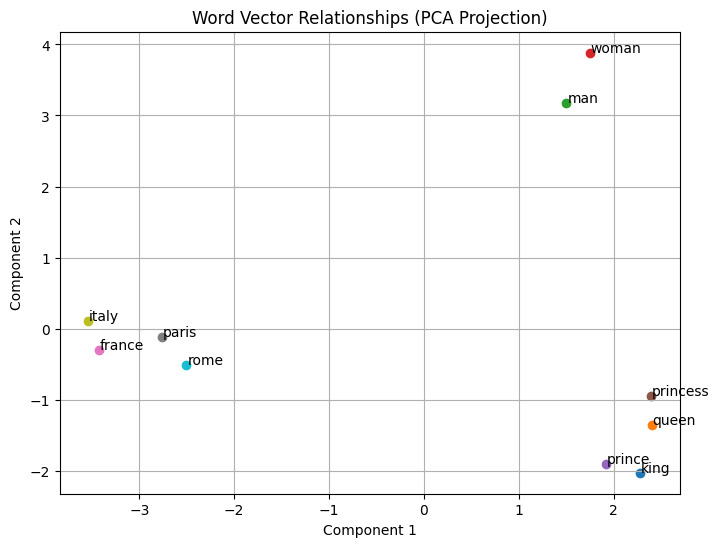

In [ ]:
!pip install gensim numpy matplotlib scikit-learn


import gensim.downloader as api
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load pre-trained word vectors (GloVe, 100 dimensions)
# --------------------------------------------------
print("Loading pre-trained word vectors...")
model = api.load("glove-wiki-gigaword-100")
print("Model loaded!")
print("Vector size:", model.vector_size)

# --------------------------------------------------
# Function: cosine similarity between two words
# --------------------------------------------------
def word_similarity(word1, word2):
    sim = model.similarity(word1, word2)
    print(f"Similarity between '{word1}' and '{word2}': {sim:.4f}")

# --------------------------------------------------
# Function: word analogy (vector arithmetic)
# --------------------------------------------------
def word_analogy(positive, negative, topn=5):
    print(f"\nAnalogy: {positive} - {negative}")
    results = model.most_similar(
        positive=positive,
        negative=negative,
        topn=topn
    )
    for word, score in results:
        print(f"{word:10s} {score:.4f}")

# --------------------------------------------------
# Similarity examples
# --------------------------------------------------
print("\n--- Word Similarities ---")
word_similarity("king", "queen")
word_similarity("king", "car")
word_similarity("paris", "france")

# --------------------------------------------------
# Vector arithmetic examples
# --------------------------------------------------
print("\n--- Vector Arithmetic Examples ---")

# king - man + woman = queen
word_analogy(positive=["king", "woman"], negative=["man"])

# france - paris + rome = italy (or similar)
word_analogy(positive=["france", "rome"], negative=["paris"])

# walking - walk + swim ≈ swimming
word_analogy(positive=["walking", "swim"], negative=["walk"])

# --------------------------------------------------
# Bias example (for analysis, not truth)
# --------------------------------------------------
print("\n--- Bias Demonstration (for analysis) ---")
word_analogy(positive=["doctor", "woman"], negative=["man"])

# --------------------------------------------------
# Visualization using PCA
# --------------------------------------------------
print("\nVisualizing word relationships...")

words = [
    "king", "queen", "man", "woman",
    "prince", "princess", "france", "paris",
    "italy", "rome"
]

vectors = np.array([model[word] for word in words])

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8, 6))
for word, (x, y) in zip(words, reduced_vectors):
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("Word Vector Relationships (PCA Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


Loading GloVe Model (100D)... Please wait.
Model Loaded Successfully!

Words used for visualization:
['computer', 'software', 'hardware', 'internet', 'network', 'database', 'algorithm', 'python', 'cloud', 'security']

Total words: 10

Dimensionality Reduction Completed!
Reduced shape: (10, 2)


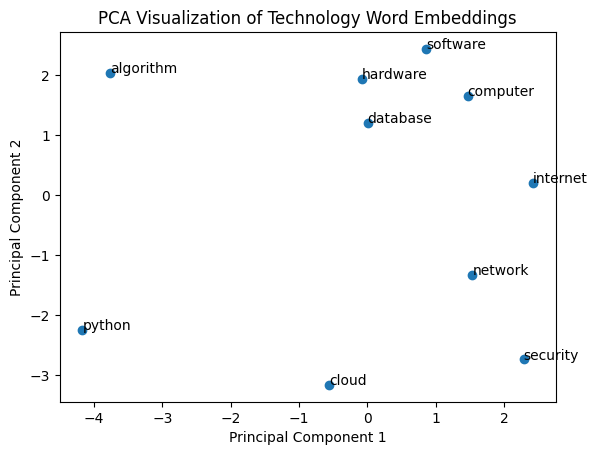


--- Similarity Analysis ---

Similarity between computer & software: 0.8373
Similarity between internet & network: 0.71
Similarity between python & algorithm: 0.1881

Top 5 similar words for 'computer':

computers  (Score: 0.8752)
software  (Score: 0.8373)
technology  (Score: 0.7642)
pc  (Score: 0.7366)
hardware  (Score: 0.7290)

Contextual Output:
Cloud is strongly related to clouds, ash, dust, sky, mist, showing semantic connections in the technology domain.


In [ ]:
!pip install gensim scikit-learn matplotlib --quiet

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# STEP 3: Load Pretrained Word Embeddings
# ==========================================
print("Loading GloVe Model (100D)... Please wait.")
model = api.load("glove-wiki-gigaword-100")
print("Model Loaded Successfully!\n")

# ==========================================
# STEP 4: Select 10 Words (Technology Domain)
# ==========================================
tech_words = [
    "computer", "software", "hardware", "internet", "network",
    "database", "algorithm", "python", "cloud", "security"
]

word_vectors = []
valid_words = []

for word in tech_words:
    if word in model:
        word_vectors.append(model[word])
        valid_words.append(word)

word_vectors = np.array(word_vectors)

print("Words used for visualization:")
print(valid_words)
print("\nTotal words:", len(valid_words))

# ==========================================
# STEP 5: Dimensionality Reduction (PCA)
# ==========================================
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

print("\nDimensionality Reduction Completed!")
print("Reduced shape:", reduced_vectors.shape)

# ==========================================
# STEP 6: Visualization
# ==========================================
plt.figure()
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("PCA Visualization of Technology Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# ==========================================
# STEP 7: Cluster & Similarity Analysis
# ==========================================
print("\n--- Similarity Analysis ---\n")

print("Similarity between computer & software:",
      round(model.similarity("computer", "software"), 4))

print("Similarity between internet & network:",
      round(model.similarity("internet", "network"), 4))

print("Similarity between python & algorithm:",
      round(model.similarity("python", "algorithm"), 4))

# ==========================================
# STEP 8: Generate 5 Semantically Similar Words
# ==========================================
def get_similar_words(word):
    if word in model:
        print(f"\nTop 5 similar words for '{word}':\n")
        similar = model.most_similar(word, topn=5)
        for w, score in similar:
            print(f"{w}  (Score: {score:.4f})")
    else:
        print("Word not found in vocabulary.")

# Example
get_similar_words("computer")

# ==========================================
# STEP 9: Generate Contextually Rich Output
# ==========================================
def generate_context(word):
    if word in model:
        similar_words = [w for w, _ in model.most_similar(word, topn=5)]
        sentence = f"{word.capitalize()} is strongly related to " + ", ".join(similar_words) + \
                   ", showing semantic connections in the technology domain."
        return sentence
    else:
        return "Word not found in vocabulary."

print("\nContextual Output:")
print(generate_context("cloud"))


In [ ]:
!pip install gensim --quiet

# ==========================================
# STEP 2: Import Libraries
# ==========================================
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# ==========================================
# STEP 3: Create Domain-Specific Corpus (Medical)
# ==========================================

medical_corpus = [
    "The doctor prescribed antibiotics for the infection",
    "The patient was diagnosed with diabetes and hypertension",
    "Surgery was performed to remove the tumor",
    "The nurse monitored the patient's vital signs",
    "Cardiology deals with heart related diseases",
    "Neurology focuses on brain and nervous system disorders",
    "The hospital provides emergency medical services",
    "Cancer treatment includes chemotherapy and radiation therapy",
    "The pharmacist dispensed the prescribed medication",
    "The diagnosis was confirmed after laboratory tests"
]

# Preprocess text (tokenization)
processed_corpus = [simple_preprocess(sentence) for sentence in medical_corpus]

print("Processed Corpus:\n")
for sentence in processed_corpus:
    print(sentence)

# ==========================================
# STEP 4: Train Custom Word2Vec Model
# ==========================================

model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,   # Embedding dimension
    window=5,
    min_count=1,
    workers=4
)

print("\nWord2Vec Model Trained Successfully!\n")

# ==========================================
# STEP 5: Find Similar Words
# ==========================================

def get_similar_words(word):
    print(f"\nTop 5 similar words for '{word}':\n")
    similar_words = model.wv.most_similar(word, topn=5)
    for w, score in similar_words:
        print(f"{w}  (Score: {score:.4f})")

# Example
get_similar_words("doctor")

# ==========================================
# STEP 6: Similarity Analysis
# ==========================================

print("\nSimilarity Scores:\n")
print("doctor & nurse:",
      round(model.wv.similarity("doctor", "nurse"), 4))

print("cancer & tumor:",
      round(model.wv.similarity("cancer", "tumor"), 4))

print("brain & heart:",
      round(model.wv.similarity("brain", "heart"), 4))

# ==========================================
# STEP 7: Contextual Sentence Generation
# ==========================================

def generate_context(word):
    similar = [w for w, _ in model.wv.most_similar(word, topn=3)]
    sentence = f"In medical context, {word} is closely associated with {', '.join(similar)}."
    return sentence

print("\nContextual Output:")
print(generate_context("cancer"))



Processed Corpus:

['the', 'doctor', 'prescribed', 'antibiotics', 'for', 'the', 'infection']
['the', 'patient', 'was', 'diagnosed', 'with', 'diabetes', 'and', 'hypertension']
['surgery', 'was', 'performed', 'to', 'remove', 'the', 'tumor']
['the', 'nurse', 'monitored', 'the', 'patient', 'vital', 'signs']
['cardiology', 'deals', 'with', 'heart', 'related', 'diseases']
['neurology', 'focuses', 'on', 'brain', 'and', 'nervous', 'system', 'disorders']
['the', 'hospital', 'provides', 'emergency', 'medical', 'services']
['cancer', 'treatment', 'includes', 'chemotherapy', 'and', 'radiation', 'therapy']
['the', 'pharmacist', 'dispensed', 'the', 'prescribed', 'medication']
['the', 'diagnosis', 'was', 'confirmed', 'after', 'laboratory', 'tests']

Word2Vec Model Trained Successfully!


Top 5 similar words for 'doctor':

after  (Score: 0.2398)
was  (Score: 0.2017)
brain  (Score: 0.1945)
deals  (Score: 0.1766)
for  (Score: 0.1576)

Similarity Scores:

doctor & nurse: -0.0958
cancer & tumor: -0.1023
b

In [ ]:
!pip install gensim transformers torch --quiet

# ==========================================
# STEP 2: Import Libraries
# ==========================================
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from transformers import pipeline

# ==========================================
# STEP 3: Create a Small Domain Corpus (AI Domain)
# ==========================================
ai_corpus = [
    "Artificial intelligence improves automation",
    "Machine learning algorithms learn from data",
    "Deep learning uses neural networks",
    "Natural language processing enables chatbots",
    "AI helps in robotics and autonomous systems",
    "Data science uses statistics and machine learning",
    "Neural networks power modern AI applications",
    "AI models generate text images and speech",
    "Chatbots use natural language understanding",
    "Automation increases productivity using AI"
]

# Preprocess text
processed_corpus = [simple_preprocess(sentence) for sentence in ai_corpus]

print("Processed Corpus:\n")
for s in processed_corpus:
    print(s)

# ==========================================
# STEP 4: Train Word2Vec Model
# ==========================================

model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("\nWord2Vec Model Trained Successfully!\n")

# ==========================================
# STEP 5: Retrieve Similar Words
# ==========================================

word = "ai"
similar_words = model.wv.most_similar(word, topn=3)

print("Similar words for 'ai':\n")
for w, score in similar_words:
    print(w, ":", round(score,4))

# ==========================================
# STEP 6: Create Original and Enriched Prompts
# ==========================================

original_prompt = "Explain the benefits of AI in healthcare."

similar_list = [w for w,_ in similar_words]

enriched_prompt = f"Explain the benefits of AI, {similar_list[0]}, {similar_list[1]}, and {similar_list[2]} in healthcare."

print("\nOriginal Prompt:")
print(original_prompt)

print("\nEnriched Prompt:")
print(enriched_prompt)

# ==========================================
# STEP 7: Load Generative AI Model
# ==========================================

generator = pipeline("text-generation", model="gpt2")

# ==========================================
# STEP 8: Generate Responses
# ==========================================

original_output = generator(original_prompt, max_length=60, num_return_sequences=1)
enriched_output = generator(enriched_prompt, max_length=60, num_return_sequences=1)

print("\nResponse for Original Prompt:\n")
print(original_output[0]['generated_text'])

print("\nResponse for Enriched Prompt:\n")
print(enriched_output[0]['generated_text'])



Processed Corpus:

['artificial', 'intelligence', 'improves', 'automation']
['machine', 'learning', 'algorithms', 'learn', 'from', 'data']
['deep', 'learning', 'uses', 'neural', 'networks']
['natural', 'language', 'processing', 'enables', 'chatbots']
['ai', 'helps', 'in', 'robotics', 'and', 'autonomous', 'systems']
['data', 'science', 'uses', 'statistics', 'and', 'machine', 'learning']
['neural', 'networks', 'power', 'modern', 'ai', 'applications']
['ai', 'models', 'generate', 'text', 'images', 'and', 'speech']
['chatbots', 'use', 'natural', 'language', 'understanding']
['automation', 'increases', 'productivity', 'using', 'ai']

Word2Vec Model Trained Successfully!

Similar words for 'ai':

use : 0.2194
data : 0.2162
autonomous : 0.1959

Original Prompt:
Explain the benefits of AI in healthcare.

Enriched Prompt:
Explain the benefits of AI, use, data, and autonomous in healthcare.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Response for Original Prompt:

Explain the benefits of AI in healthcare.

5. Achieving the best outcomes for patients with cancer

Some cancer patients might not be able to afford cancer treatment, but they are able to afford it.

It is possible that, at some point, you will need to choose between life-saving treatments or you may not be able to afford treatment at all.

You might need to choose between life-saving treatments, or you may not.

Your cancer patients are more likely than other patients to be willing to go on-the-road and take on a journey that involves high risk.

So, in order to become more proactive about cancer care, we need to get our patients on the road right away with cancer treatments and we need to get them on the road for cancer treatment.

Response for Enriched Prompt:

Explain the benefits of AI, use, data, and autonomous in healthcare.

In the abstract, "The benefits of AI are well-established," and this has been confirmed by the results of the 2016 National

In [ ]:
!pip install gensim nltk

# ----------------------------------------
# STEP 0: Install required libraries
# (Run this only in Jupyter/Colab)
# ----------------------------------------
try:
    import gensim
except ImportError:
    !pip install gensim nltk

# ----------------------------------------
# STEP 1: Import libraries
# ----------------------------------------
import nltk
from gensim.models import Word2Vec
from nltk.corpus import brown

# ----------------------------------------
# STEP 2: Download dataset
# ----------------------------------------
nltk.download('brown')

# ----------------------------------------
# STEP 3: Load and preprocess data
# ----------------------------------------
sentences = brown.sents()
processed_sentences = [[word.lower() for word in sent] for sent in sentences]

# ----------------------------------------
# STEP 4: Train Word2Vec model
# ----------------------------------------
model = Word2Vec(
    processed_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# ----------------------------------------
# STEP 5: Take input from user
# ----------------------------------------
seed_word = input("Enter a seed word: ").lower()

# ----------------------------------------
# STEP 6: Get similar words
# ----------------------------------------
try:
    similar_words = model.wv.most_similar(seed_word, topn=5)
    similar_words = [word for word, score in similar_words]
except KeyError:
    print("❌ Word not found in vocabulary. Try another word.")
    exit()

print("\n✅ Similar Words:", similar_words)

# ----------------------------------------
# STEP 7: Generate paragraph/story
# ----------------------------------------
def generate_paragraph(seed, words):
    paragraph = (
        f"\nOnce upon a time, there was a {seed} who lived in a distant land. "
        f"One day, it met a {words[0]} and a {words[1]} who became its companions. "
        f"Together, they explored places that were {words[2]} and magical. "
        f"They faced many challenges but stayed {words[3]} and brave. "
        f"In the end, the {seed} realized that being {words[4]} is the key to happiness."
    )
    return paragraph

story = generate_paragraph(seed_word, similar_words)

# ----------------------------------------
# STEP 8: Display output
# ----------------------------------------
print("\n📝 Generated Paragraph:")
print(story)


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Enter a seed word: king

✅ Similar Words: ['colonel', 'california', 'drums', '$20', 'genius']

📝 Generated Paragraph:

Once upon a time, there was a king who lived in a distant land. One day, it met a colonel and a california who became its companions. Together, they explored places that were drums and magical. They faced many challenges but stayed $20 and brave. In the end, the king realized that being genius is the key to happiness.


In [ ]:
!pip install transformers torch

"""
==========================================================
Sentiment Analysis using Hugging Face Transformers
==========================================================
Author  : Your Name
Purpose : Analyze sentiment of input text using a
          pre-trained transformer model
==========================================================
"""

# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================
from transformers import pipeline
from typing import List, Dict

# ==========================================
# CLASS: SentimentAnalyzer
# ==========================================
class SentimentAnalyzer:
    """
    A class to handle sentiment analysis using Hugging Face pipeline
    """

    def __init__(self, model_name: str = None):
        """
        Initialize the sentiment analysis pipeline

        :param model_name: Optional custom model
        """
        try:
            if model_name:
                self.analyzer = pipeline("sentiment-analysis", model=model_name)
            else:
                self.analyzer = pipeline("sentiment-analysis")

            print("[INFO] Sentiment model loaded successfully.")

        except Exception as e:
            print("[ERROR] Failed to load model:", e)
            raise

    def analyze(self, texts: List[str]) -> List[Dict]:
        """
        Perform sentiment analysis

        :param texts: List of input sentences
        :return: List of sentiment results
        """
        try:
            results = self.analyzer(texts)
            return results
        except Exception as e:
            print("[ERROR] Analysis failed:", e)
            return []

    def display_results(self, texts: List[str], results: List[Dict]) -> None:
        """
        Display formatted output
        :param texts: Input sentences
        :param results: Model predictions
        """
        print("\n========== SENTIMENT ANALYSIS RESULTS ==========\n")

        for idx, (text, result) in enumerate(zip(texts, results), start=1):
            print(f"[{idx}] Sentence       : {text}")
            print(f"    Sentiment      : {result['label']}")
            print(f"    Confidence     : {result['score']:.4f}")
            print("-" * 60)

# ==========================================
# FUNCTION: Load Sample Data
# ==========================================
def load_sample_data() -> List[str]:
    """
    Load sample sentences (simulating real-world input)
    """
    return [
        "I absolutely love this product!",
        "This is the worst experience ever.",
        "The service was okay, nothing special.",
        "Very fast delivery and great support.",
        "I am unhappy with the performance."
    ]

# ==========================================
# MAIN FUNCTION
# ==========================================
def main():
    """
    Main execution function
    """
    print("\n[INFO] Starting Sentiment Analysis Application...\n")

    # Step 1: Initialize Analyzer
    analyzer = SentimentAnalyzer()

    # Step 2: Load Data
    sentences = load_sample_data()

    # Step 3: Perform Analysis
    results = analyzer.analyze(sentences)

    # Step 4: Display Output
    analyzer.display_results(sentences, results)

# ==========================================
# ENTRY POINT
# ==========================================
if __name__ == "__main__":
    main()



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



[INFO] Starting Sentiment Analysis Application...



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[INFO] Sentiment model loaded successfully.

========== SENTIMENT ANALYSIS RESULTS ==========

[1] Sentence       : I absolutely love this product!
    Sentiment      : POSITIVE
    Confidence     : 0.9999
------------------------------------------------------------
[2] Sentence       : This is the worst experience ever.
    Sentiment      : NEGATIVE
    Confidence     : 0.9998
------------------------------------------------------------
[3] Sentence       : The service was okay, nothing special.
    Sentiment      : NEGATIVE
    Confidence     : 0.9862
------------------------------------------------------------
[4] Sentence       : Very fast delivery and great support.
    Sentiment      : POSITIVE
    Confidence     : 0.9999
------------------------------------------------------------
[5] Sentence       : I am unhappy with the performance.
    Sentiment      : NEGATIVE
    Confidence     : 0.9998
------------------------------------------------------------
